# NorthStar Urban Mobility and Logistics
## Notebook 3: R Analytics and Visualisation

This notebook performs statistical analysis and visualisation using R to identify trends and patterns in NorthStar's operational data.

The analysis focuses on:

- Customer complaint patterns
- Delivery performance
- Driver performance
- Monthly trends
- Relationships between deliveries and complaints

Install Required Packages

In [16]:
# Install required packages
system("apt-get update -qq")
system("apt-get install -y r-cran-ggplot2 r-cran-dplyr")

Load Libraries

In [17]:
library(ggplot2)
library(dplyr)

cat("Libraries loaded successfully.\n")

Libraries loaded successfully.


## Load Cleaned Data from GitHub

In [18]:
# GitHub username
github_username <- "haamnaaa"

# Base URL for cleaned data
base_url <- paste0(
  "https://raw.githubusercontent.com/haamnaaa/DBA-Files/main/cleaned_data/northstar_cleaned_data/"
)

cat(base_url)

https://raw.githubusercontent.com/haamnaaa/DBA-Files/main/cleaned_data/northstar_cleaned_data/

Load Datasets

In [4]:
# Load cleaned datasets
complaints <- read.csv(paste0(base_url, "complaints_clean.csv"))
deliveries <- read.csv(paste0(base_url, "deliveries_clean.csv"))
drivers <- read.csv(paste0(base_url, "drivers_clean.csv"))
orders <- read.csv(paste0(base_url, "orders_clean.csv"))

cat("Datasets loaded successfully.\n")

Datasets loaded successfully.


Inspect Column Names

In [5]:
# Check available columns
colnames(complaints)
colnames(deliveries)
colnames(drivers)
colnames(orders)

[1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation_amount"

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"

[1] "driver_id"        "base_zone"        "employment_type"  "years_experience"
[5] "training_score"   "driver_rating"    "shift_preference" "active_flag"

[1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

## Analysis 1: Most Common Complaint Types

This analysis identifies the complaint categories that occur most frequently.

In [6]:
# Count complaints by type
complaint_summary <- complaints %>%
  group_by(complaint_type) %>%
  summarise(total_complaints = n()) %>%
  arrange(desc(total_complaints))

# Display results
complaint_summary

complaint_type,total_complaints
<chr>,<int>
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


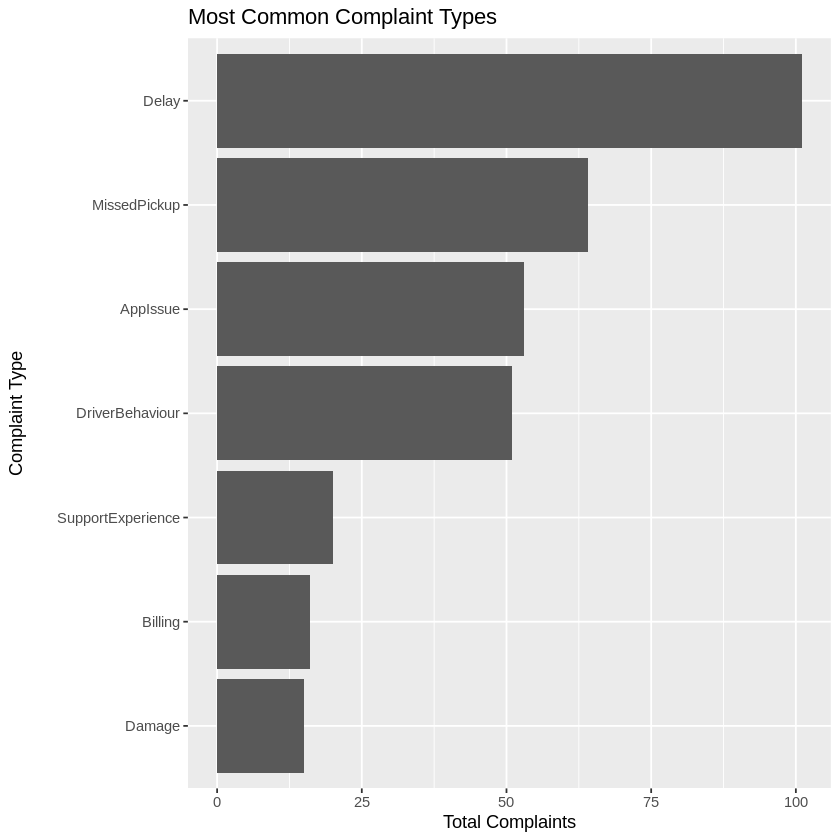

In [7]:
ggplot(complaint_summary,
       aes(x = reorder(complaint_type, total_complaints),
           y = total_complaints)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Most Common Complaint Types",
    x = "Complaint Type",
    y = "Total Complaints"
  )

### Interpretation

This chart shows the most common reasons customers submit complaints.

If categories such as late delivery, failed service, or damaged goods appear most frequently, this indicates weaknesses in operational execution and customer service.

## Analysis 2: Delivery Status Distribution

In [8]:
# Count deliveries by status
delivery_summary <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(total_deliveries = n()) %>%
  arrange(desc(total_deliveries))

delivery_summary

delivery_status,total_deliveries
<chr>,<int>
OnTime,616
Delayed,202
Failed,132


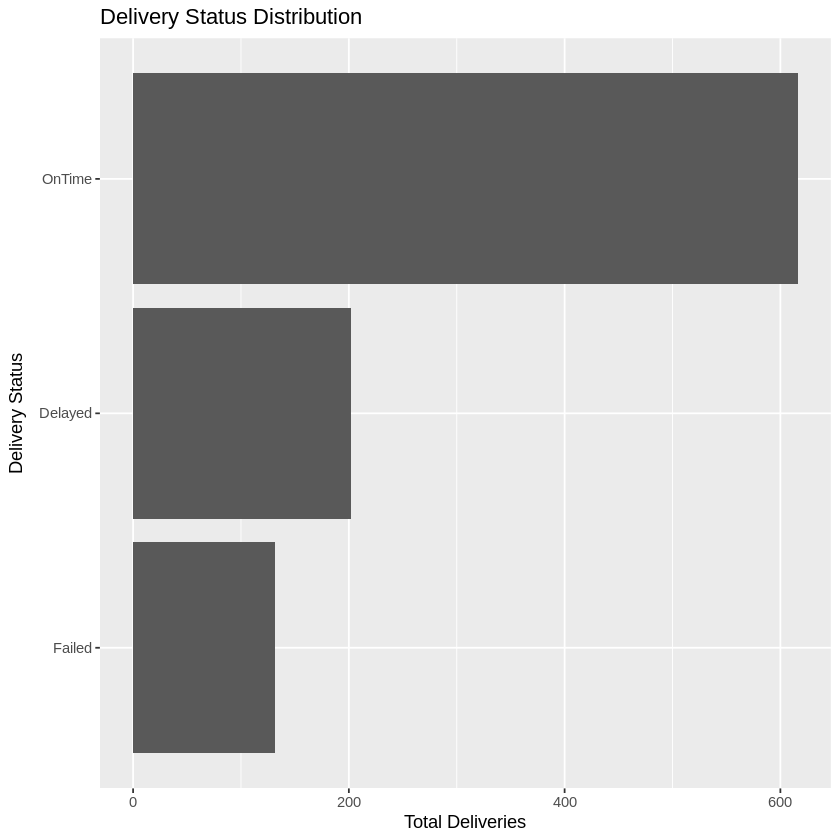

In [9]:
ggplot(delivery_summary,
       aes(x = reorder(delivery_status, total_deliveries),
           y = total_deliveries)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Total Deliveries"
  )

## Analysis 3: Incident Severity Distribution

In [10]:
# Load incidents data
incidents <- read.csv(paste0(base_url, "incidents_clean.csv"))

# Count incidents by severity
incident_summary <- incidents %>%
  group_by(severity) %>%
  summarise(total_incidents = n()) %>%
  arrange(desc(total_incidents))

incident_summary

severity,total_incidents
<chr>,<int>
Medium,106
Low,79
High,68
Critical,27


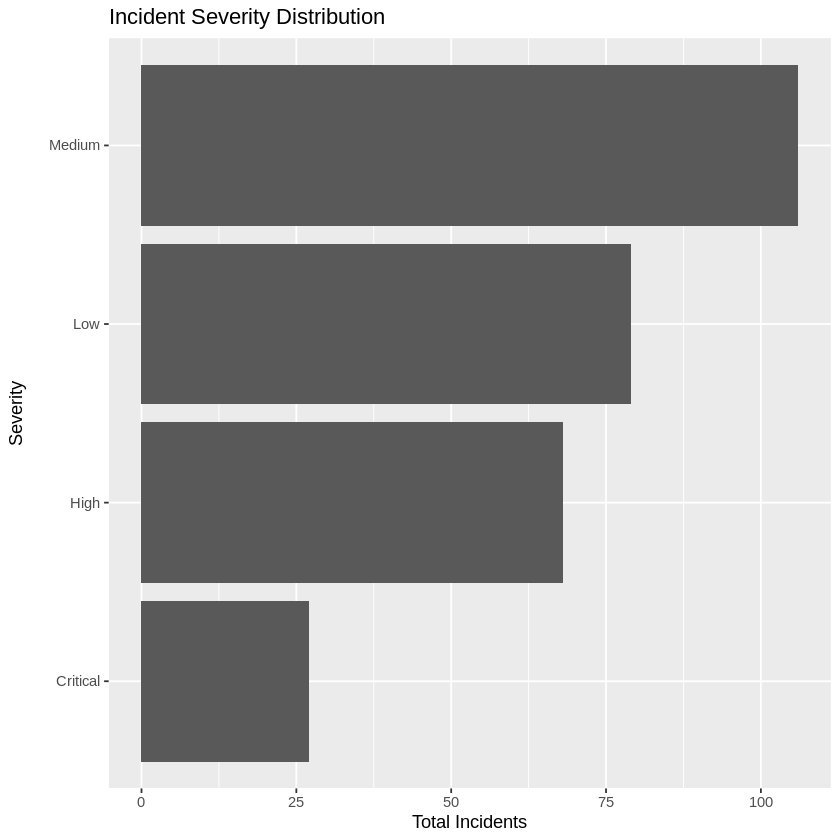

In [11]:
ggplot(incident_summary,
       aes(x = reorder(severity, total_incidents),
           y = total_incidents)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Incident Severity Distribution",
    x = "Severity",
    y = "Total Incidents"
  )

### Interpretation

A high number of medium- and high-severity incidents may indicate driver safety issues, inadequate maintenance, or operational control weaknesses.

## Analysis 4: Monthly Complaint Trend

In [12]:
# Convert complaint date to Date format
# First, check column names to ensure 'complaint_date' exists
# print(colnames(complaints)) # Already inspected
# Then, inspect the content of the column
# print(head(complaints$complaint_date)) # Already inspected, confirmed absence

complaints$complaint_date <- as.Date(complaints$created_at)

# Extract month
complaints$month <- format(complaints$complaint_date, "%Y-%m")

# Count complaints per month
monthly_complaints <- complaints %>%
  group_by(month) %>%
  summarise(total_complaints = n()) %>%
  arrange(month)

monthly_complaints

month,total_complaints
<chr>,<int>
2024-01,16
2024-02,9
2024-03,20
2024-04,19
2024-05,6
2024-06,16
2024-07,15
2024-08,16
2024-09,15


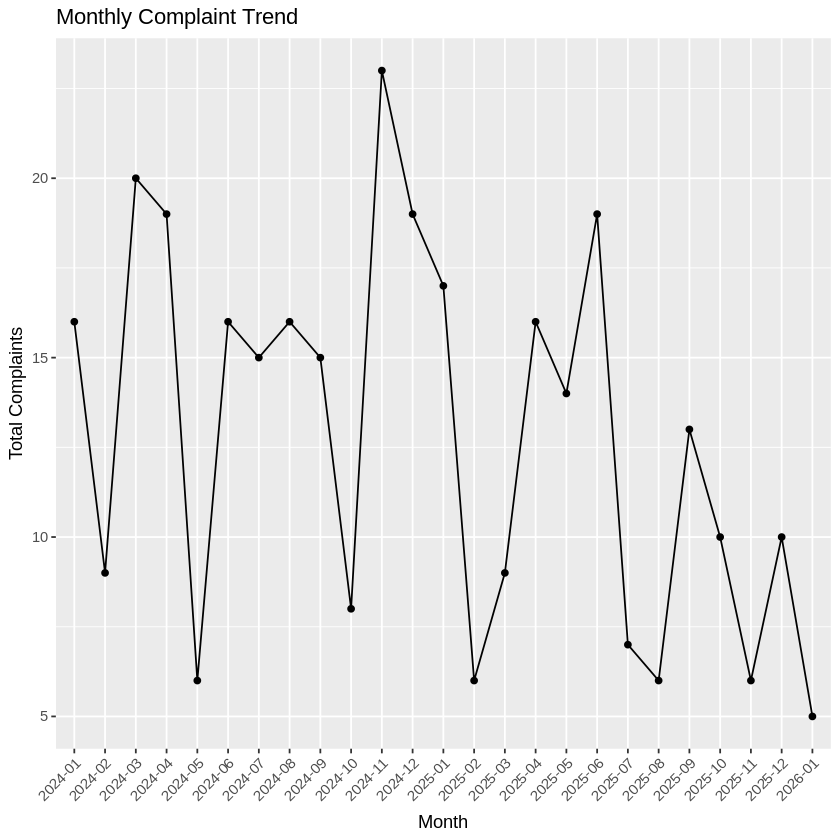

In [13]:
ggplot(monthly_complaints,
       aes(x = month, y = total_complaints, group = 1)) +
  geom_line() +
  geom_point() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(
    title = "Monthly Complaint Trend",
    x = "Month",
    y = "Total Complaints"
  )

### Interpretation

An increasing trend in complaints suggests that service quality is deteriorating over time.

## Analysis 5: Deliveries vs Complaints by Service Type

In [14]:
# Inspect column names to find 'service_type'
# print(colnames(deliveries))
# print(colnames(orders))

# Count deliveries by service type
delivery_counts <- deliveries %>%
  inner_join(orders, by = "order_id") %>%
  group_by(service_type) %>%
  summarise(total_deliveries = n())

# Count complaints by service type
complaint_counts <- complaints %>%
  inner_join(orders, by = "order_id") %>%
  group_by(service_type) %>%
  summarise(total_complaints = n())

# Merge both tables
combined <- merge(delivery_counts,
                  complaint_counts,
                  by = "service_type",
                  all = TRUE) # Use all = TRUE to keep all service types, even if one count is zero

# Replace NA with 0 for better representation
combined[is.na(combined)] <- 0

combined

service_type,total_deliveries,total_complaints
<chr>,<int>,<int>
Business,126,39
Medical,108,37
Parcel,230,77
Passenger,262,84
Retail,224,83


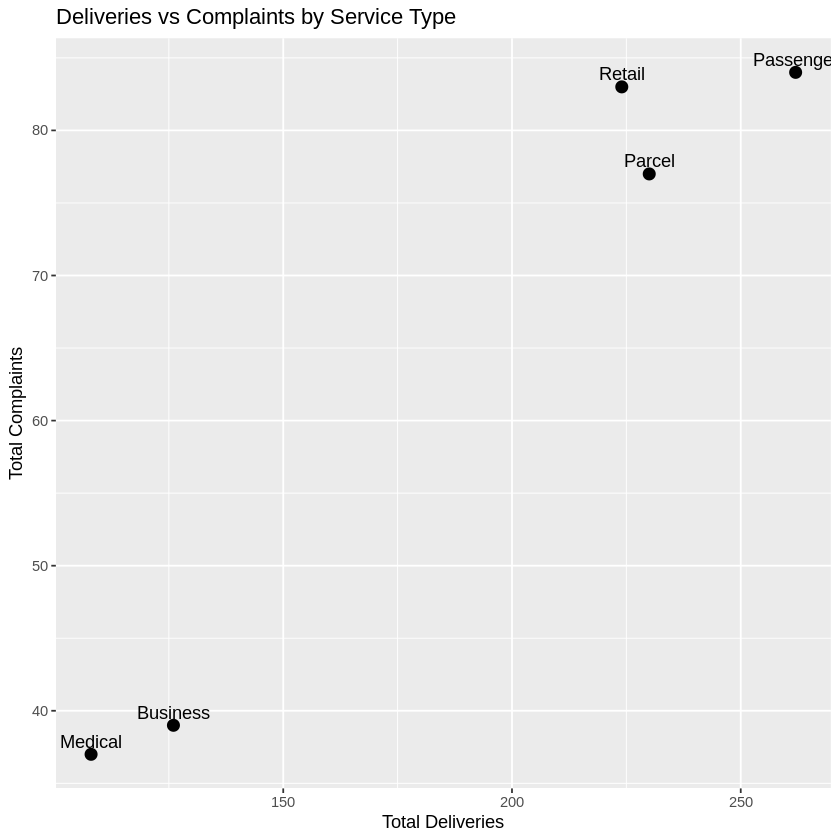

In [15]:
ggplot(combined,
       aes(x = total_deliveries,
           y = total_complaints,
           label = service_type)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.5) +
  labs(
    title = "Deliveries vs Complaints by Service Type",
    x = "Total Deliveries",
    y = "Total Complaints"
  )

### Interpretation

Service types with high complaint levels relative to delivery volume may be structurally underperforming and require operational redesign.

## Summary of R Analytics

This notebook identified several important patterns:

- The most common complaint categories.
- Distribution of delivery outcomes.
- Incident severity levels.
- Monthly complaint trends.
- Service types with disproportionately high complaint volumes.

These findings provide evidence of declining service reliability and operational inefficiencies across NorthStar.